# Introduction into the effect of site


Magnetic Resonance Imaging (MRI) studies are increasingly conducted across multiple imaging sites and scanners in order to collect larger and more diverse datasets. While multi-site studies improve statistical power and generalisability, they also introduce an important challenge: site effects (sometimes called scanner effects or batch effects).

Site effects arise because MRI measurements can vary depending on:

- Scanner manufacturer and model

- Imaging protocols and acquisition parameters

- Hardware calibration

- Coil differences

- Software versions

- Environmental and operational factors

Even when imaging protocols are carefully harmonised, subtle differences between scanners can still influence the appearance of images and the quantitative measures derived from them.

In this tutorial, we will explore how image-level differences propagate into downstream analyses and how these effects can bias statistical interpretation if they are not properly considered.

### Tutorial contents

- Identify visual differences between MRI scans acquired at different sites

- Understand how scanner effects influence image intensity distributions and image quality metrics

- Explore how derived imaging phenotypes (IDPs) can vary across scanners

- Simulate multi-site datasets with batch effects

- Understand how confounding variables and scanner effects can distort biological interpretation

- Reflect on why harmonisation methods are important in large neuroimaging studies

## Section 1.1: Exploring image level differences

We will begin by examining structural MRI data from the *ON-Harmony travelling-heads study* [1]. In this dataset, the same participant was scanned at multiple imaging sites, allowing us to isolate scanner-related differences while keeping biological variation constant.

The acquisition protocols in this study were designed to be as consistent as possible across scanners. Despite this harmonisation effort, measurable differences still remain between images. The data have also been defaced according to UK Biobank protocols to protect participant privacy. This preprocessing step does not affect the derived brain measurements used in this tutorial.

We will begin by viewing some data from the ON-Harmony study using a single image viewer.
This data is from one participant, at two different sites.[1]

We show here only the T1 data as the most commonly use modality. The imaging acquisition for this data was made to be as homogenous as possible. Data has been defaced following UKB protocol but derived metrics will be unaffected by this.

As you inspect the scans, think carefully about the following:

Do the overall image intensities appear similar?

- Are some images noisier than others?

- Does tissue contrast differ between scans?

- Are anatomical boundaries equally clear?

- Could these differences influence automated measurements such as hippocampal volume or cortical thickness?

- These observations will motivate the later statistical analyses in the notebook.



In [ ]:
from block1_helper_functions.ImageViewerBlock1 import MRIImageViewer
import matplotlib.pyplot as plt 
import pathlib

# 1. Display the example data from one subject in two different sessions using the provided viewer:
#  notebooks/block01/data/*.nii
DATA_DIR = pathlib.Path("../../data/data_block1")
# Load the images, they are converted to arrays for ease within the MRIimage viewer class
img1 = DATA_DIR / "Philips.nii"
img2 = DATA_DIR / "GE.nii"

viewer1 = MRIImageViewer(img1, img2)
viewer1.show()

## Section 1.2: Basic image level statistics

As previosuly mentioned, the protocols in this study were designed to be as similar to eachother as scanners were allowed to be. Despite this, the overall intensities, SNR, CNR and even brain anatomy looks incredible different.

Still working at the image level; we can view some of these differences as plots.

- Histogram of intensities 

- Number of non-zero voxels


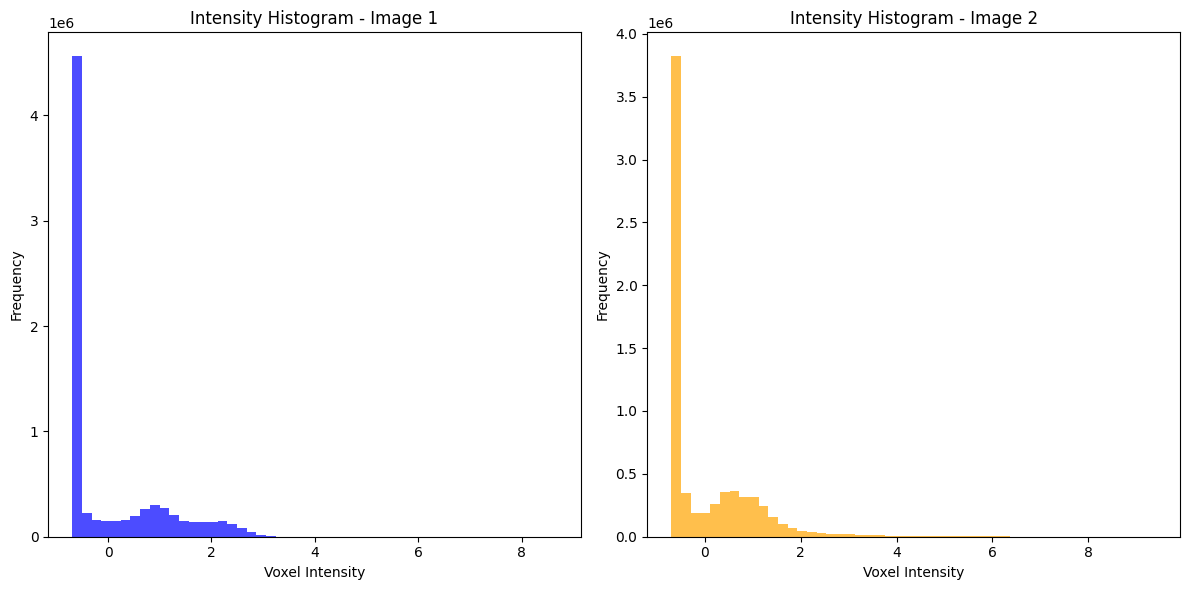

Image 1 - Non-zero voxel count: 55.39%
Image 2 - Non-zero voxel count: 89.06%


(np.float64(0.5539327891260533), np.float64(0.8905881504340408))

In [ ]:
from block1_helper_functions.ImageStatsBlock1 import IntensityHistogram
from block1_helper_functions.ImageStatsBlock1 import NonZeroVoxelCount

IntensityHistogram(img1, img2)

# Count the number of non-zero voxels in each image, divide by total number of voxels to get the percentage of non-zero voxels, and print the results.

NonZeroVoxelCount(img1, img2)

## Section 1.3: ROI/IDP differences due to scanner effects:

Directly comparing the brains in this case might be best done using non-linear registration to standard space (MNI152). 
Here we used FNIRT on both brains, with the settings described at the bottom of the images. [2][3][4]

Differences observed at the image level often propagate into downstream quantitative measurements.

To compare anatomical structures more meaningfully across scans, MRI images are typically aligned to a standard anatomical space such as MNI152 using image registration techniques such as FSL FNIRT.[2][3][4]
After spatial normalisation, we can estimate regional brain measurements such as:

- Regional volumes

- Cortical measurements

- Tissue properties

- Morphometric biomarkers

These measurements are often referred to as Imaging-Derived Phenotypes (IDPs).
In doing so, we are able to compare different regional volumes in a more meaningful way. The full processing of this data is described in the ON-Harmony dataset and we only use the IDPs here;

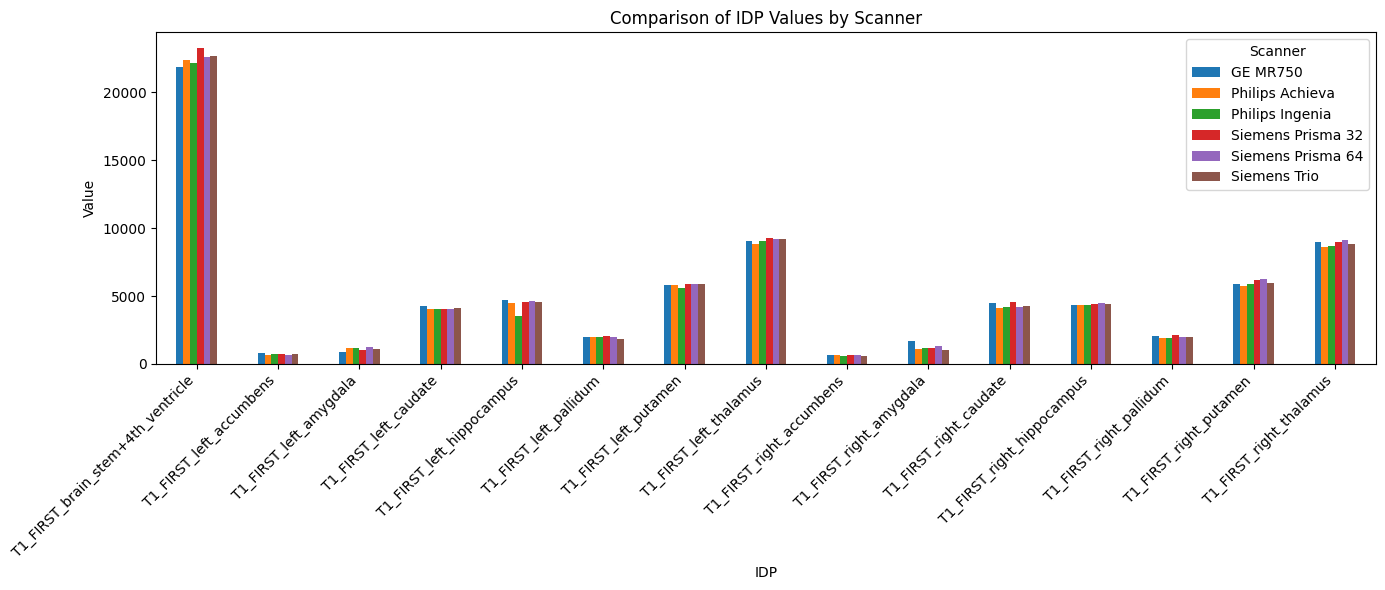

image_id                           GE MR750  Philips Achieva  Philips Ingenia  \
IDP                                                                             
T1_FIRST_brain_stem+4th_ventricle   21896.0          22400.0          22194.0   
T1_FIRST_left_accumbens               796.0            673.0            717.0   
T1_FIRST_left_amygdala                859.0           1171.0           1169.0   
T1_FIRST_left_caudate                4243.0           4011.0           4043.0   
T1_FIRST_left_hippocampus            4676.0           4494.0           3559.0   
T1_FIRST_left_pallidum               1985.0           1977.0           1966.0   
T1_FIRST_left_putamen                5820.0           5830.0           5604.0   
T1_FIRST_left_thalamus               9081.0           8861.0           9044.0   
T1_FIRST_right_accumbens              661.0            651.0            614.0   
T1_FIRST_right_amygdala              1686.0           1067.0           1169.0   
T1_FIRST_right_caudate      

In [ ]:
# Comparing the IDPs from FSL-FIRST of different ROIs across the two sessions, and plotting the results.
from block1_helper_functions.ImageStatsBlock1 import compareIDPs
compareIDPs(DATA_DIR / "ON_Harmony_example_IDPs.csv")

## Section 1.4: Sample differences between scanners and sites

**Modelling a single IDP**

Now we have established that image level differences will propogate into even the most simple derived metrics, such as volume measurements, we will look at using simulated tabular data to look at how this may affect pooled, multi-site datasets.

In the most simple modelling approach, an individual measurement for one individual (for example, hippocampal volume) for participant i at site j can be expressed as a simple linear model of the form below:

$ y_{ij} = \alpha_j + \epsilon_{ij}$

Where:

- $y_{ij}$ is the observed measurement

- $\alpha_j$ is the average value at site $j$

- $\epsilon_{ij}$ represents subject-level variation and noise

This assumes that a single measurement, for example the volume, is just a linear combination of the mean volume of that ROI, plus some subject specific effect $\epsilon$

**Incorporating Biological Covariates**

However, we know that volumes will be affected by many other variables, such as age, sex, height, weight or disease. As such, a better simulated model will also include terms for these measures, and potentially interactions between them (such as age $\times$ sex).

The most simple model, assuming no interactions, is then:

$ y_{ij} = \alpha_j + X_i \beta_j + \epsilon_{ij}$

Have a look at what this looks like below; Here we simulate three batches all drawn from the same normal distribution and then choose site/batch specific population characteristics. These will share the same fixed effects, but different distributions among sites.

Have a go at changing these characteristics below in the GUI and look at the resulting histograms.

**As you work through the simulations, consider:**

- Which variables are true biological effects?
- Which variables might act as confounds?
- What happens if site and biological variables become correlated?



In [ ]:
from block1_helper_functions.SimulateDataBlock1 import make_simulator_input_gui
_ = make_simulator_input_gui()

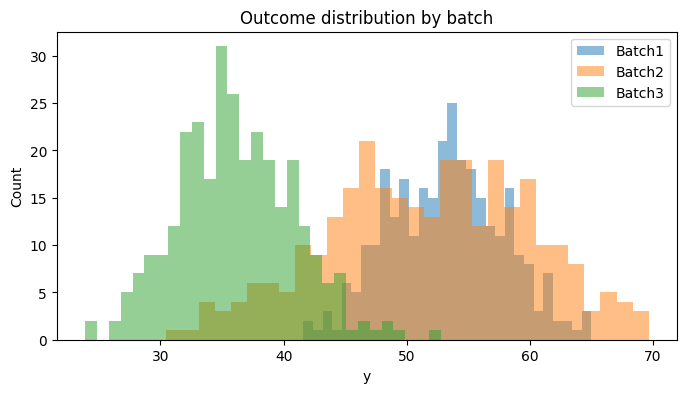

In [ ]:
from block1_helper_functions.SimulateDataBlock1 import simulate_batched_data

data =[]
params = make_simulator_input_gui.last_result
data = params["data"]
batch = params["batch"]
covariate_specs = params["covariate_specs"]
betas = params["betas"]
batch_params = params["batch_params"]

df = simulate_batched_data(
    data=data,
    batch=batch,
    covariate_specs=covariate_specs,
    betas=betas,
    noise_sd=1.0,
    seed=123,
)
df.head()

plt.figure(figsize=(8, 4))
for b in df["batch"].unique():
    plt.hist(df.loc[df["batch"] == b, "y"], bins=30, alpha=0.5, label=b)
plt.legend()
plt.title("Outcome distribution by batch")
plt.xlabel("y")
plt.ylabel("Count")
plt.show()

After generating the simulated dataset, we can visualise how imaging measurements change across explanatory variables such as age.

One useful visualisation is a nomogram (or percentile chart), which shows how a measurement varies across the population.

Nomograms are commonly used to:

- Estimate expected values for a given age

- Identify individuals outside the normal range

- Model developmental and ageing trajectories

- Compare patient groups against normative populations

In neuroimaging, nomograms are increasingly used to create reference charts across the lifespan, for further reading on normative modelling and brain charts, see Bethlehem et al. [5].

As you inspect the plots:

- Do the simulated relationships look biologically realistic?
- Which variables appear most strongly associated with the outcome?
- How much variation exists within the population?



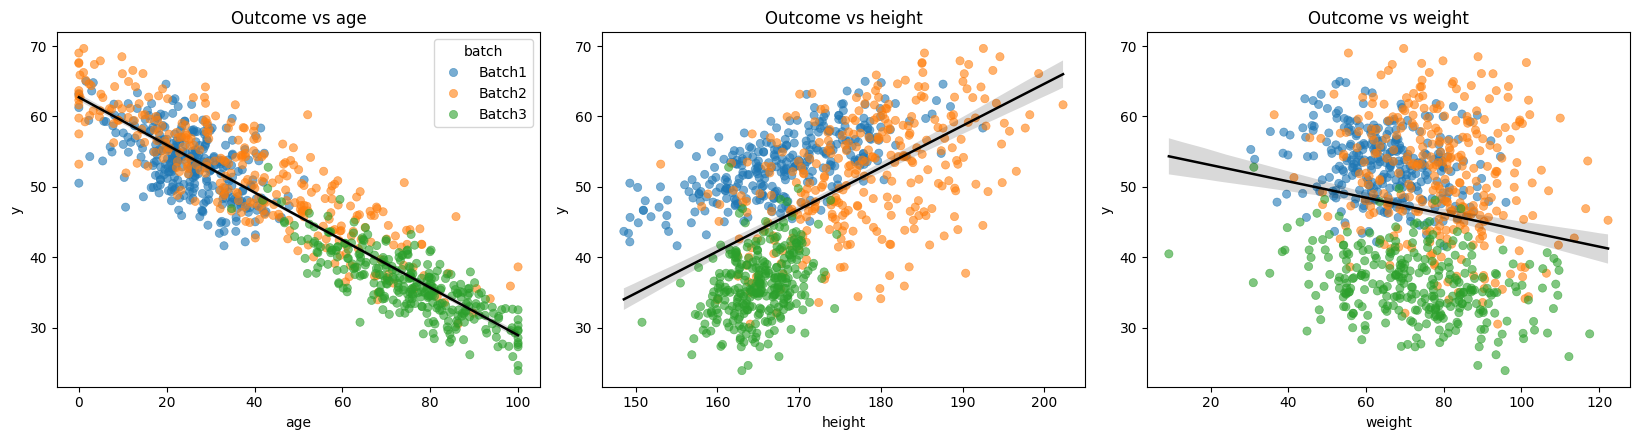

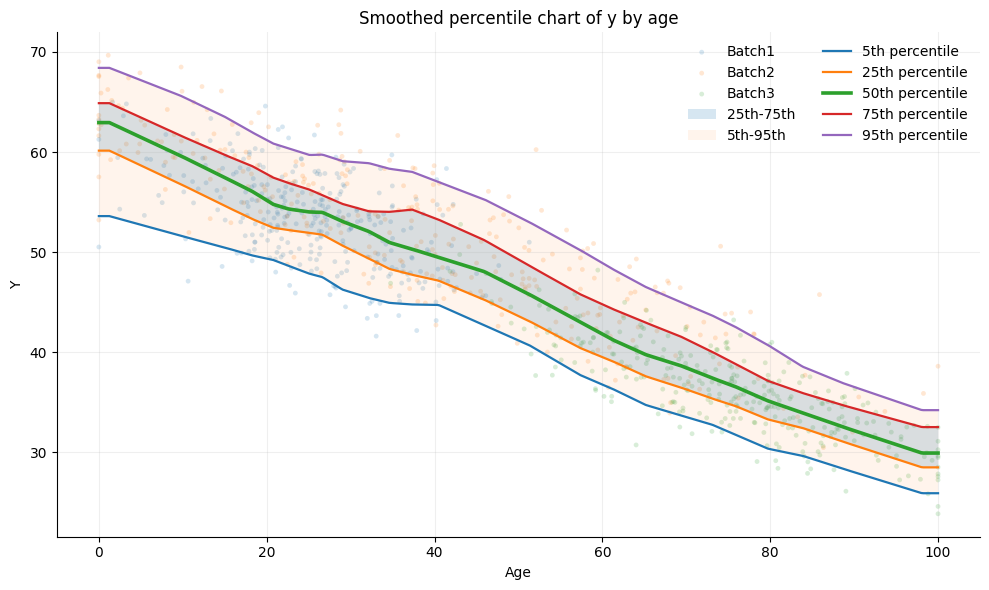

In [ ]:
from block1_helper_functions.PlottingBlock1 import plot_charts, plot_age_percentile_chart

fig = plot_charts(df, ["age", "height", "weight"], batch_col="batch", outcome_col="y")

# Also show the age nomogram:

fig, ax = plot_age_percentile_chart(
    df,
    age_col="age",
    value_col="y",
    batch_col="batch",
    n_bins=25,
    smooth_frac=0.25,
    show_points=True,
    show_batch_coloring=True,
)

plt.show()

## Section 1.5: Non-biological site differences

So far, we have simulated biological variation without major scanner-related distortions. We will now introduce explicit batch effects into the dataset.

Batch effects can alter both:

- The mean of a measurement distribution

- The variance of the measurement distribution

A commonly used harmonisation framework (such as ComBat) models the data using an expression similar to:

$ y_{ij} = \alpha_j + X_i \beta_j +  X_i \beta_{batch} + \delta_{batch} \times \epsilon_{ij}$

- $\alpha_j$ represents the baseline mean

- $X_i \beta_j$ captures biological covariate effects

- $X_i \beta_{batch}$ represents additive batch effects

- $\delta_{batch}$ represents multiplicative variance effects

- $\epsilon_{ij}$ is residual error


Batch effects can produce misleading conclusions if not properly accounted for.

For example: A disease group may appear different simply because most patients were scanned at one site or scanner differences may mask genuine biological relationships.

As you explore the simulations, think carefully about:

- Which effects are biological?

- Which are scanner-related?

- How difficult would it be to separate these effects in a real study?


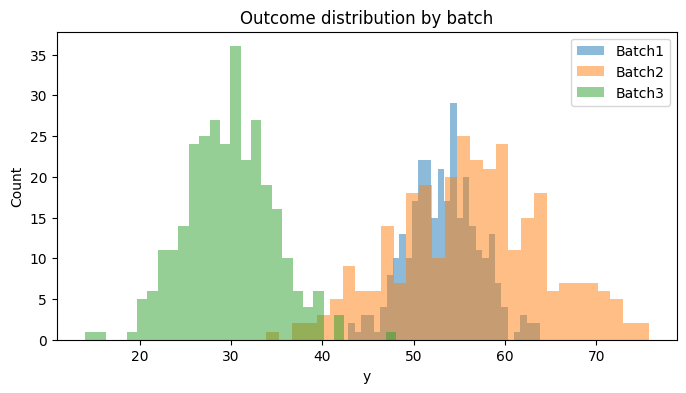

In [ ]:
from block1_helper_functions.SimulateDataBlock1 import simulate_batched_data

# Add some batch effects to the data and see how they impact the distribution of the outcome variable. 
# We will simulate data with 3 batches, each with different covariate distributions and batch effects.
batch_params = {
    "Batch1": {"add_mean": 0.00, "add_sd": 0.05, "multi_mean": 1.00, "multi_shape": 25.0},
    "Batch2": {"add_mean": 5, "add_sd": 0.08, "multi_mean": 1.5, "multi_shape": 18.0},
    "Batch3": {"add_mean": -7, "add_sd": 0.06, "multi_mean": 0.8, "multi_shape": 30.0},
}
# Recreate the data this time with the batch effects:
df2 = simulate_batched_data(
    data=data,
    batch=batch,
    covariate_specs=covariate_specs,
    betas=betas,
    batch_params=batch_params,
    noise_sd=1.0,
    relative_batch_effects=True,
    seed=42,
)
df2.head()

plt.figure(figsize=(8, 4))
for b in df2["batch"].unique():
    plt.hist(df2.loc[df2["batch"] == b, "y"], bins=30, alpha=0.5, label=b)
plt.legend()
plt.title("Outcome distribution by batch")
plt.xlabel("y")
plt.ylabel("Count")
plt.show()


After introducing batch effects, the relationships between imaging measurements and explanatory variables become much harder to interpret.

In many cases:

- Correlations weaken

- Variability increases

- Site-specific clusters emerge

- Biological trends become obscured

This is one of the central challenges of multi-site neuroimaging. Even relatively small scanner effects can distort normative trajectories, bias machine learning models, reduce reproducibility and produce spurious findings.

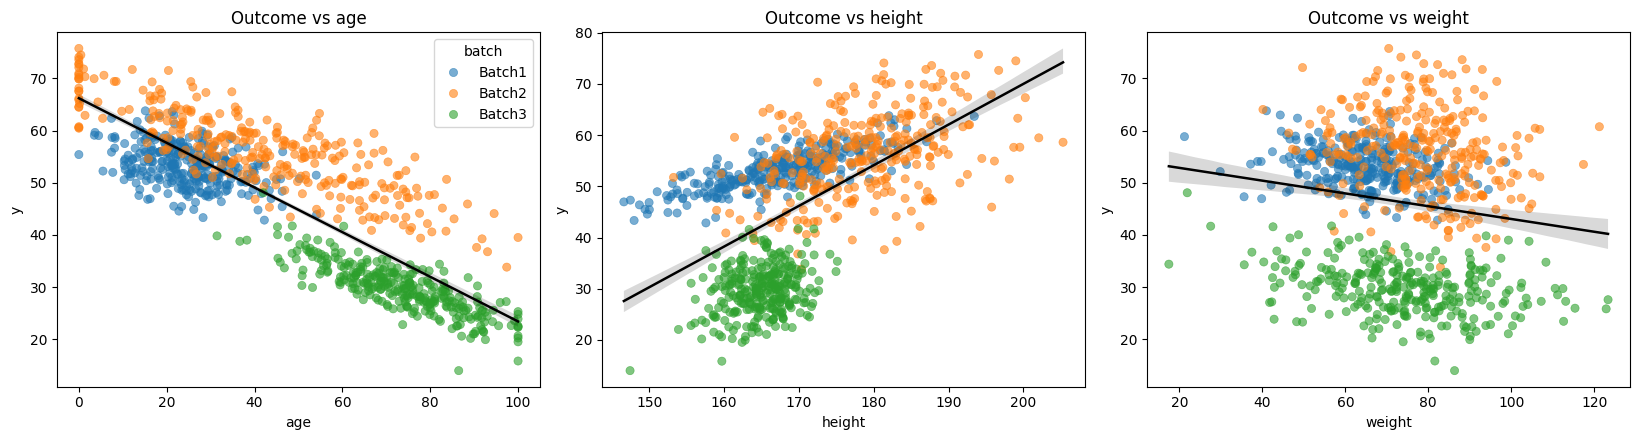

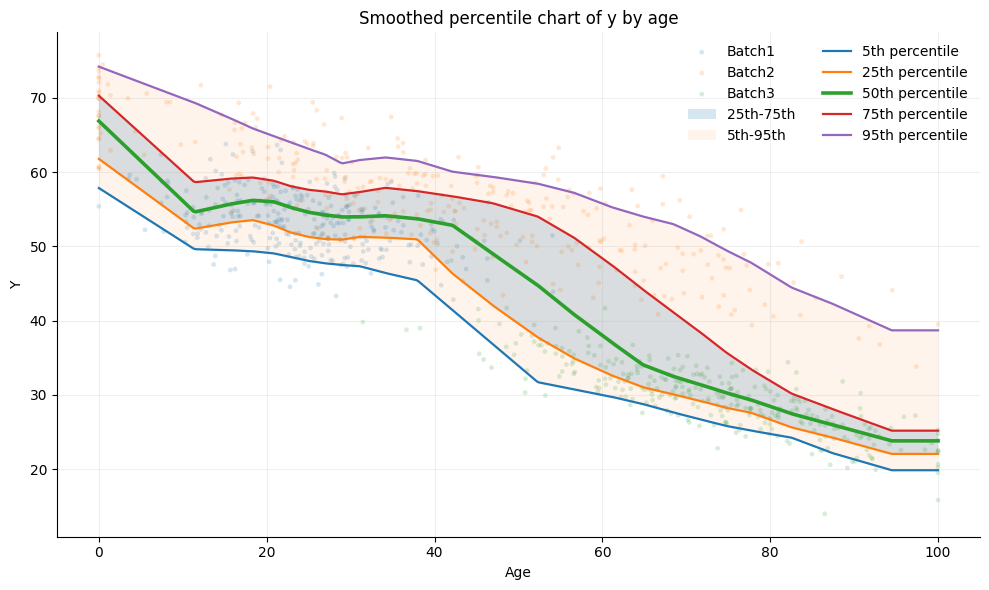

In [ ]:
from block1_helper_functions.PlottingBlock1 import plot_charts
fig = plot_charts(df2, ["age", "height", "weight"], batch_col="batch", outcome_col="y")

fig, ax = plot_age_percentile_chart(
    df2,
    age_col="age",
    value_col="y",
    batch_col="batch",
    n_bins=25,
    smooth_frac=0.25,
    show_points=True,
    show_batch_coloring=True,
)

## Summary:

*In this tutorial, we explored how scanner and site effects can influence neuroimaging data at multiple levels, from raw image appearance to derived quantitative measurements and downstream statistical analyses. While multi-site studies are essential for building large and representative datasets, they also introduce technical variability that can obscure true biological effects if not carefully accounted for. Understanding, identifying, and mitigating these sources of variation is therefore a critical part of modern neuroimaging research. As imaging datasets continue to grow in scale and complexity, robust harmonisation strategies and thoughtful study design will remain essential for ensuring reliable, reproducible, and biologically meaningful results.*



# Citations:
[1] Warrington, S., Torchi, A., Mougin, O. et al. A multi-site, multi-modal travelling-heads resource for brain MRI harmonisation. Sci Data 12, 609 (2025). https://doi.org/10.1038/s41597-025-04822-2

[2] M.W. Woolrich, S. Jbabdi, B. Patenaude, M. Chappell, S. Makni, T. Behrens, C. Beckmann, M. Jenkinson, S.M. Smith. Bayesian analysis of neuroimaging data in FSL. NeuroImage, 45:S173-86, 2009

[3] S.M. Smith, M. Jenkinson, M.W. Woolrich, C.F. Beckmann, T.E.J. Behrens, H. Johansen-Berg, P.R. Bannister, M. De Luca, I. Drobnjak, D.E. Flitney, R. Niazy, J. Saunders, J. Vickers, Y. Zhang, N. De Stefano, J.M. Brady, and P.M. Matthews. Advances in functional and structural MR image analysis and implementation as FSL. NeuroImage, 23(S1):208-19, 2004

[4] M. Jenkinson, C.F. Beckmann, T.E. Behrens, M.W. Woolrich, S.M. Smith. FSL. NeuroImage, 62:782-90, 2012

[5] Bethlehem, R.A.I., Seidlitz, J., White, S.R. et al. Brain charts for the human lifespan. Nature 604, 525–533 (2022). https://doi.org/10.1038/s41586-022-04554-y

